# Robustness and comparisons

This notebook evaluates whether local counterfactual support contains
information beyond simpler geometric notions of extrapolation.

It deliberately keeps the comparison set compact:

1. within-state support–disagreement relationships;
2. controlled regressions against distance and range diagnostics;
3. panel-clustered uncertainty for the main decomposition;
4. leave-one-product-out influence;
5. spline-clipping and candidate-grid boundary checks.

The notebook treats the empirical architecture and support threshold as
frozen. It does not re-estimate demand models or retune the pricing rule.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import spearmanr

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)

CURRENT_DIR = Path.cwd().resolve()
POSSIBLE_ROOTS = [
    CURRENT_DIR,
    CURRENT_DIR.parent,
]

PROJECT_ROOT = next(
    (
        root
        for root in POSSIBLE_ROOTS
        if (
            root
            / "data"
            / "processed"
        ).is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root from "
        f"{CURRENT_DIR}"
    )

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)
TABLE_DIR = (
    PROJECT_ROOT
    / "results"
    / "tables"
)
FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)
MODEL_DIR = (
    PROJECT_ROOT
    / "results"
    / "models"
)

for directory in [
    TABLE_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

CANDIDATE_PATH = (
    PROCESSED_DIR
    / "candidate_price_support_and_predictions.pkl"
)
POLICY_PATH = (
    PROCESSED_DIR
    / "support_aware_policy_choices.pkl"
)
DECOMPOSITION_PATH = (
    PROCESSED_DIR
    / "price_of_extrapolation_decomposition.pkl"
)
CONFIGURATION_PATH = (
    MODEL_DIR
    / "price_of_extrapolation_configuration.json"
)

PRIMARY_EVALUATION_SPLIT = "test"
BOOTSTRAP_REPLICATIONS = 500
RANDOM_STATE = 42
NUMERICAL_TOLERANCE = 1e-10

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])

Project root: C:\Users\janza\price-of-extrapolation
Python: 3.13.3


## 2. Load and validate the frozen empirical outputs

In [3]:
required_paths = [
    CANDIDATE_PATH,
    POLICY_PATH,
    DECOMPOSITION_PATH,
    CONFIGURATION_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.is_file()
]

if missing_paths:
    raise FileNotFoundError(
        "Run the main price-of-extrapolation notebook first. "
        "Missing files:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )

candidates = pd.read_pickle(
    CANDIDATE_PATH
)
policy_choices = pd.read_pickle(
    POLICY_PATH
)
decomposition = pd.read_pickle(
    DECOMPOSITION_PATH
)
configuration = json.loads(
    CONFIGURATION_PATH.read_text(
        encoding="utf-8"
    )
)

SELECTED_SUPPORT_THRESHOLD = float(
    configuration[
        "selected_support_threshold"
    ]
)

required_candidate_columns = {
    "decision_id",
    "evaluation_split",
    "store",
    "upc",
    "store_upc",
    "week",
    "support_state",
    "candidate_price",
    "candidate_reference_price",
    "candidate_reference_distance",
    "candidate_observed_distance",
    "objective_ppml",
    "local_support_state",
    "nearest_price_distance_state",
    "outside_historical_range_state",
    "model_disagreement_log_demand",
    "candidate_spline_clipped",
}

required_policy_columns = {
    "decision_id",
    "evaluation_split",
    "store",
    "upc",
    "store_upc",
    "week",
    "support_state",
    "candidate_price",
    "candidate_reference_price",
    "candidate_reference_distance",
    "candidate_observed_distance",
    "objective_ppml",
    "local_support_state",
    "nearest_price_distance_state",
    "outside_historical_range_state",
    "model_disagreement_log_demand",
    "policy",
}

required_decomposition_columns = {
    "decision_id",
    "evaluation_split",
    "store",
    "upc",
    "store_upc",
    "week",
    "support_state",
    "nominal_gain",
    "price_of_extrapolation",
    "nominal_price_is_unsupported",
    "local_support_state_nominal",
    "model_disagreement_log_demand_nominal",
}

missing_candidate_columns = (
    required_candidate_columns
    .difference(candidates.columns)
)
missing_policy_columns = (
    required_policy_columns
    .difference(policy_choices.columns)
)
missing_decomposition_columns = (
    required_decomposition_columns
    .difference(decomposition.columns)
)

if missing_candidate_columns:
    raise ValueError(
        "Missing candidate columns: "
        f"{sorted(missing_candidate_columns)}"
    )

if missing_policy_columns:
    raise ValueError(
        "Missing policy columns: "
        f"{sorted(missing_policy_columns)}"
    )

if missing_decomposition_columns:
    raise ValueError(
        "Missing decomposition columns: "
        f"{sorted(missing_decomposition_columns)}"
    )

duplicate_policy_rows = (
    policy_choices.duplicated(
        ["decision_id", "policy"]
    )
)

if duplicate_policy_rows.any():
    raise ValueError(
        "Policy choices contain duplicate "
        "decision-policy rows."
    )

print(
    "Selected support threshold:",
    SELECTED_SUPPORT_THRESHOLD,
)
print(
    "Candidate rows:",
    f"{len(candidates):,}",
)
print(
    "Decisions:",
    f"{candidates['decision_id'].nunique():,}",
)
print(
    "Policy rows:",
    f"{len(policy_choices):,}",
)
print(
    "Decomposition rows:",
    f"{len(decomposition):,}",
)
print(
    "Objective:",
    configuration.get(
        "objective_type",
        "unknown",
    ),
)

display(
    decomposition.groupby(
        [
            "evaluation_split",
            "support_state",
        ],
        observed=True,
    )
    .size()
    .rename("decisions")
    .reset_index()
)

Selected support threshold: 0.5
Candidate rows: 51,704
Decisions: 16,111
Policy rows: 64,444
Decomposition rows: 16,111
Objective: revenue


,evaluation_split,support_state,decisions
0,policy_calibration,post_promotion,405
1,policy_calibration,promotion,996
2,policy_calibration,regular,6360
3,test,post_promotion,621
4,test,promotion,1112
5,test,regular,6617


## 3. Construct the nominal-recommendation analysis sample

The robustness checks are decision-level analyses of the price selected
by the nominal optimizer. Candidate-level information is merged back only
to recover spline-clipping and grid-boundary indicators.

In [4]:
nominal = (
    policy_choices.loc[
        policy_choices[
            "policy"
        ].eq("nominal")
    ]
    .copy()
    .drop(
        columns=[
            "fallback_used",
        ],
        errors="ignore",
    )
)

nominal = nominal.merge(
    decomposition[
        [
            "decision_id",
            "nominal_gain",
            "price_of_extrapolation",
            "nominal_price_is_unsupported",
        ]
    ],
    on="decision_id",
    how="left",
    validate="one_to_one",
)

candidate_boundary_summary = (
    candidates.groupby(
        "decision_id",
        observed=True,
    )
    .agg(
        decision_min_candidate_price=(
            "candidate_price",
            "min",
        ),
        decision_max_candidate_price=(
            "candidate_price",
            "max",
        ),
        candidate_count=(
            "candidate_price",
            "size",
        ),
    )
    .reset_index()
)

nominal_flags = (
    candidates[
        [
            "decision_id",
            "candidate_price",
            "candidate_spline_clipped",
        ]
    ]
    .drop_duplicates(
        [
            "decision_id",
            "candidate_price",
        ]
    )
)

if nominal_flags.duplicated(
    [
        "decision_id",
        "candidate_price",
    ]
).any():
    raise ValueError(
        "Candidate prices are not unique within decision."
    )

nominal = nominal.merge(
    nominal_flags,
    on=[
        "decision_id",
        "candidate_price",
    ],
    how="left",
    validate="one_to_one",
)

nominal = nominal.merge(
    candidate_boundary_summary,
    on="decision_id",
    how="left",
    validate="one_to_one",
)

nominal[
    "nominal_price_ratio_to_reference"
] = (
    nominal["candidate_price"]
    / nominal[
        "candidate_reference_price"
    ]
)

nominal[
    "at_lower_decision_boundary"
] = np.isclose(
    nominal["candidate_price"],
    nominal[
        "decision_min_candidate_price"
    ],
    rtol=0.0,
    atol=1e-8,
)

nominal[
    "at_upper_decision_boundary"
] = np.isclose(
    nominal["candidate_price"],
    nominal[
        "decision_max_candidate_price"
    ],
    rtol=0.0,
    atol=1e-8,
)

nominal[
    "at_decision_grid_boundary"
] = (
    nominal[
        "at_lower_decision_boundary"
    ]
    | nominal[
        "at_upper_decision_boundary"
    ]
)

nominal[
    "outside_range_indicator"
] = (
    nominal[
        "outside_historical_range_state"
    ]
    .fillna(False)
    .astype(int)
)

nominal["log1p_support"] = np.log1p(
    nominal[
        "local_support_state"
    ].clip(lower=0.0)
)

nominal[
    "weak_support_score"
] = -nominal["log1p_support"]

nominal[
    "positive_nominal_gain"
] = nominal[
    "nominal_gain"
].gt(NUMERICAL_TOLERANCE)

if nominal[
    "candidate_spline_clipped"
].isna().any():
    raise ValueError(
        "Some nominal choices could not be matched "
        "to candidate-level clipping information."
    )

display(
    nominal.groupby(
        [
            "evaluation_split",
            "support_state",
        ],
        observed=True,
    )
    .agg(
        decisions=(
            "decision_id",
            "size",
        ),
        unsupported_share=(
            "nominal_price_is_unsupported",
            "mean",
        ),
        clipped_share=(
            "candidate_spline_clipped",
            "mean",
        ),
        lower_boundary_share=(
            "at_lower_decision_boundary",
            "mean",
        ),
        upper_boundary_share=(
            "at_upper_decision_boundary",
            "mean",
        ),
        mean_candidate_count=(
            "candidate_count",
            "mean",
        ),
    )
    .reset_index()
)

,evaluation_split,support_state,decisions,unsupported_share,clipped_share,lower_boundary_share,upper_boundary_share,mean_candidate_count
0,policy_calibration,post_promotion,405,0.066667,0.002469,1.000000,0.377778,3.602469
1,policy_calibration,promotion,996,0.196787,0.019076,0.980924,0.099398,9.817269
2,policy_calibration,regular,6360,0.000000,0.019182,0.995283,0.686478,1.840566
3,test,post_promotion,621,0.022544,0.000000,1.000000,0.352657,4.657005
4,test,promotion,1112,0.111511,0.011691,0.987410,0.053957,10.811151
5,test,regular,6617,0.000000,0.000000,1.000000,0.663745,2.092640


## 4. Within-state diagnostic relationships

These estimates test whether the pooled support–disagreement association
is merely a consequence of promotions having both lower support and
larger modeling difficulty.

In [5]:
def safe_spearman(
    x: pd.Series,
    y: pd.Series,
) -> tuple[float, float, int]:
    valid = pd.DataFrame(
        {
            "x": pd.to_numeric(
                x,
                errors="coerce",
            ),
            "y": pd.to_numeric(
                y,
                errors="coerce",
            ),
        }
    ).dropna()

    if (
        len(valid) < 10
        or valid["x"].nunique() < 2
        or valid["y"].nunique() < 2
    ):
        return np.nan, np.nan, len(valid)

    rho, p_value = spearmanr(
        valid["x"],
        valid["y"],
    )
    return (
        float(rho),
        float(p_value),
        len(valid),
    )


correlation_rows = []

for (
    evaluation_split,
    support_state,
), group in nominal.groupby(
    [
        "evaluation_split",
        "support_state",
    ],
    observed=True,
):
    diagnostics = {
        "local_support": (
            group[
                "local_support_state"
            ]
        ),
        "reference_distance": (
            group[
                "candidate_reference_distance"
            ]
        ),
        "nearest_historical_distance": (
            group[
                "nearest_price_distance_state"
            ]
        ),
        "outside_historical_range": (
            group[
                "outside_range_indicator"
            ]
        ),
    }

    for diagnostic, values in diagnostics.items():
        rho, p_value, n = safe_spearman(
            values,
            group[
                "model_disagreement_log_demand"
            ],
        )

        correlation_rows.append(
            {
                "evaluation_split": (
                    evaluation_split
                ),
                "support_state": (
                    support_state
                ),
                "diagnostic": diagnostic,
                "n": n,
                "spearman_rho": rho,
                "p_value": p_value,
            }
        )

within_state_correlations = (
    pd.DataFrame(
        correlation_rows
    )
    .sort_values(
        [
            "evaluation_split",
            "support_state",
            "diagnostic",
        ]
    )
    .reset_index(drop=True)
)

display(
    within_state_correlations
)

,evaluation_split,support_state,diagnostic,n,spearman_rho,p_value
0,policy_calibration,post_promotion,local_support,405,0.131371,8.118715e-03
1,policy_calibration,post_promotion,nearest_historical_distance,405,-0.055225,2.675161e-01
2,policy_calibration,post_promotion,outside_historical_range,405,-0.465873,3.278991e-23
3,policy_calibration,post_promotion,reference_distance,405,-0.502778,2.475580e-27
4,policy_calibration,promotion,local_support,996,-0.239184,2.004351e-14
5,policy_calibration,promotion,nearest_historical_distance,996,0.326624,3.429472e-26
6,policy_calibration,promotion,outside_historical_range,996,-0.345570,2.581111e-29
7,policy_calibration,promotion,reference_distance,996,-0.704401,3.849267e-150
8,policy_calibration,regular,local_support,6360,-0.088760,1.329494e-12
9,policy_calibration,regular,nearest_historical_distance,6360,0.125577,8.948197e-24


## 5. Controlled disagreement regressions

The nested models ask whether support adds information beyond pricing
state, store, product, distance from the reference price, distance from
the nearest historical price, and historical-range membership.

Continuous diagnostics are standardized within each evaluation split.
Standard errors are clustered by store–product panel.

In [6]:
def standardize_series(
    values: pd.Series,
) -> pd.Series:
    numeric = pd.to_numeric(
        values,
        errors="coerce",
    )
    scale = numeric.std(ddof=0)

    if (
        not np.isfinite(scale)
        or scale <= 0
    ):
        return numeric * 0.0

    return (
        numeric - numeric.mean()
    ) / scale


def fit_disagreement_models(
    frame: pd.DataFrame,
    evaluation_split: str,
) -> tuple[
    dict[str, object],
    pd.DataFrame,
]:
    data = frame.loc[
        frame[
            "evaluation_split"
        ].eq(evaluation_split)
    ].copy()

    regression_columns = [
        "model_disagreement_log_demand",
        "local_support_state",
        "candidate_reference_distance",
        "nearest_price_distance_state",
        "outside_range_indicator",
        "support_state",
        "store",
        "upc",
        "store_upc",
    ]

    data = data[
        regression_columns
    ].replace(
        [np.inf, -np.inf],
        np.nan,
    ).dropna()

    data[
        "z_log1p_support"
    ] = standardize_series(
        np.log1p(
            data[
                "local_support_state"
            ].clip(lower=0.0)
        )
    )
    data[
        "z_reference_distance"
    ] = standardize_series(
        data[
            "candidate_reference_distance"
        ]
    )
    data[
        "z_nearest_distance"
    ] = standardize_series(
        data[
            "nearest_price_distance_state"
        ]
    )

    base_terms = (
        "C(support_state) "
        "+ C(store) "
        "+ C(upc)"
    )

    formulas = {
        "base_fixed_effects": (
            "model_disagreement_log_demand "
            f"~ {base_terms}"
        ),
        "reference_distance": (
            "model_disagreement_log_demand "
            f"~ {base_terms} "
            "+ z_reference_distance"
        ),
        "historical_geometry": (
            "model_disagreement_log_demand "
            f"~ {base_terms} "
            "+ z_reference_distance "
            "+ z_nearest_distance "
            "+ outside_range_indicator"
        ),
        "support_only": (
            "model_disagreement_log_demand "
            f"~ {base_terms} "
            "+ z_log1p_support"
        ),
        "full_support_geometry": (
            "model_disagreement_log_demand "
            f"~ {base_terms} "
            "+ z_reference_distance "
            "+ z_nearest_distance "
            "+ outside_range_indicator "
            "+ z_log1p_support"
        ),
    }

    fitted_models = {}
    rows = []

    for model_name, formula in formulas.items():
        fitted = smf.ols(
            formula=formula,
            data=data,
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups": data[
                    "store_upc"
                ]
            },
        )

        fitted_models[
            model_name
        ] = fitted

        support_term = (
            "z_log1p_support"
        )

        if support_term in fitted.params.index:
            support_coefficient = float(
                fitted.params[
                    support_term
                ]
            )
            support_p_value = float(
                fitted.pvalues[
                    support_term
                ]
            )
            support_ci = fitted.conf_int().loc[
                support_term
            ]
            support_ci_lower = float(
                support_ci.iloc[0]
            )
            support_ci_upper = float(
                support_ci.iloc[1]
            )
        else:
            support_coefficient = np.nan
            support_p_value = np.nan
            support_ci_lower = np.nan
            support_ci_upper = np.nan

        rows.append(
            {
                "evaluation_split": (
                    evaluation_split
                ),
                "model": model_name,
                "n": int(
                    fitted.nobs
                ),
                "r_squared": float(
                    fitted.rsquared
                ),
                "adjusted_r_squared": float(
                    fitted.rsquared_adj
                ),
                "support_coefficient": (
                    support_coefficient
                ),
                "support_ci_lower": (
                    support_ci_lower
                ),
                "support_ci_upper": (
                    support_ci_upper
                ),
                "support_p_value": (
                    support_p_value
                ),
            }
        )

    comparison = pd.DataFrame(
        rows
    )

    geometry_r2 = float(
        comparison.loc[
            comparison[
                "model"
            ].eq(
                "historical_geometry"
            ),
            "adjusted_r_squared",
        ].iloc[0]
    )

    comparison[
        "incremental_adjusted_r_squared_vs_geometry"
    ] = (
        comparison[
            "adjusted_r_squared"
        ]
        - geometry_r2
    )

    return (
        fitted_models,
        comparison,
    )


fitted_model_blocks = {}
regression_tables = []

for split_name in sorted(
    nominal[
        "evaluation_split"
    ].dropna().unique()
):
    (
        fitted_models,
        comparison,
    ) = fit_disagreement_models(
        nominal,
        evaluation_split=str(
            split_name
        ),
    )

    fitted_model_blocks[
        str(split_name)
    ] = fitted_models
    regression_tables.append(
        comparison
    )

disagreement_regression_comparison = (
    pd.concat(
        regression_tables,
        ignore_index=True,
    )
)

display(
    disagreement_regression_comparison
)

print(
    fitted_model_blocks[
        PRIMARY_EVALUATION_SPLIT
    ][
        "full_support_geometry"
    ].summary()
)

,evaluation_split,model,n,r_squared,adjusted_r_squared,support_coefficient,support_ci_lower,support_ci_upper,support_p_value,incremental_adjusted_r_squared_vs_geometry
0,policy_calibration,base_fixed_effects,7761,0.345735,0.343790,NaN,NaN,NaN,NaN,-0.203676
1,policy_calibration,reference_distance,7761,0.469450,0.467804,NaN,NaN,NaN,NaN,-0.079662
2,policy_calibration,historical_geometry,7761,0.548982,0.547466,NaN,NaN,NaN,NaN,0.000000
3,policy_calibration,support_only,7761,0.348605,0.346584,-0.023423,-0.037475,-0.009370,1.087716e-03,-0.200882
4,policy_calibration,full_support_geometry,7761,0.548994,0.547419,-0.001624,-0.012563,0.009315,7.710238e-01,-0.000047
5,test,base_fixed_effects,8350,0.295613,0.293667,NaN,NaN,NaN,NaN,-0.152661
6,test,reference_distance,8350,0.420142,0.418470,NaN,NaN,NaN,NaN,-0.027858
7,test,historical_geometry,8350,0.448052,0.446328,NaN,NaN,NaN,NaN,0.000000
8,test,support_only,8350,0.303409,0.301401,-0.041970,-0.056934,-0.027006,3.859938e-08,-0.144927
9,test,full_support_geometry,8350,0.451132,0.449351,-0.030136,-0.044822,-0.015451,5.766991e-05,0.003023


                                  OLS Regression Results                                 
Dep. Variable:     model_disagreement_log_demand   R-squared:                       0.451
Model:                                       OLS   Adj. R-squared:                  0.449
Method:                            Least Squares   F-statistic:                     75.81
Date:                           Mon, 20 Jul 2026   Prob (F-statistic):           1.77e-62
Time:                                   21:01:38   Log-Likelihood:                 5662.9
No. Observations:                           8350   AIC:                        -1.127e+04
Df Residuals:                               8322   BIC:                        -1.107e+04
Df Model:                                     27                                         
Covariance Type:                         cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--

## 6. Compact diagnostic comparison

To make the comparison interpretable, each diagnostic is added separately
to the same fixed-effect baseline. The table reports its Spearman
association with disagreement and its incremental adjusted \(R^2\).
For support, the sign is reversed so that a larger value means weaker
support.

In [7]:
def compare_single_diagnostics(
    frame: pd.DataFrame,
    evaluation_split: str,
) -> pd.DataFrame:
    data = frame.loc[
        frame[
            "evaluation_split"
        ].eq(evaluation_split)
    ].copy()

    data[
        "z_weak_support"
    ] = standardize_series(
        -np.log1p(
            data[
                "local_support_state"
            ].clip(lower=0.0)
        )
    )
    data[
        "z_reference_distance"
    ] = standardize_series(
        data[
            "candidate_reference_distance"
        ]
    )
    data[
        "z_nearest_distance"
    ] = standardize_series(
        data[
            "nearest_price_distance_state"
        ]
    )
    data[
        "outside_range_indicator"
    ] = (
        data[
            "outside_range_indicator"
        ]
        .fillna(0)
        .astype(int)
    )

    required_columns = [
        "model_disagreement_log_demand",
        "z_weak_support",
        "z_reference_distance",
        "z_nearest_distance",
        "outside_range_indicator",
        "support_state",
        "store",
        "upc",
        "store_upc",
    ]

    data = data[
        required_columns
    ].replace(
        [np.inf, -np.inf],
        np.nan,
    ).dropna()

    base_formula = (
        "model_disagreement_log_demand "
        "~ C(support_state) "
        "+ C(store) "
        "+ C(upc)"
    )

    base_model = smf.ols(
        formula=base_formula,
        data=data,
    ).fit(
        cov_type="cluster",
        cov_kwds={
            "groups": data[
                "store_upc"
            ]
        },
    )

    diagnostic_terms = {
        "weak_local_support": (
            "z_weak_support"
        ),
        "reference_price_distance": (
            "z_reference_distance"
        ),
        "nearest_historical_price_distance": (
            "z_nearest_distance"
        ),
        "outside_historical_range": (
            "outside_range_indicator"
        ),
    }

    rows = []

    for (
        diagnostic_name,
        term,
    ) in diagnostic_terms.items():
        fitted = smf.ols(
            formula=(
                base_formula
                + f" + {term}"
            ),
            data=data,
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups": data[
                    "store_upc"
                ]
            },
        )

        coefficient = float(
            fitted.params[term]
        )
        p_value = float(
            fitted.pvalues[term]
        )
        ci = fitted.conf_int().loc[
            term
        ]

        rho, rho_p_value, n = (
            safe_spearman(
                data[term],
                data[
                    "model_disagreement_log_demand"
                ],
            )
        )

        rows.append(
            {
                "evaluation_split": (
                    evaluation_split
                ),
                "diagnostic": (
                    diagnostic_name
                ),
                "n": n,
                "spearman_rho": rho,
                "spearman_p_value": (
                    rho_p_value
                ),
                "standardized_coefficient": (
                    coefficient
                ),
                "coefficient_ci_lower": float(
                    ci.iloc[0]
                ),
                "coefficient_ci_upper": float(
                    ci.iloc[1]
                ),
                "coefficient_p_value": (
                    p_value
                ),
                "incremental_adjusted_r_squared": (
                    float(
                        fitted.rsquared_adj
                        - base_model.rsquared_adj
                    )
                ),
            }
        )

    return pd.DataFrame(
        rows
    )


diagnostic_comparison = pd.concat(
    [
        compare_single_diagnostics(
            nominal,
            evaluation_split=str(
                split_name
            ),
        )
        for split_name in sorted(
            nominal[
                "evaluation_split"
            ].dropna().unique()
        )
    ],
    ignore_index=True,
)

display(
    diagnostic_comparison
)

,evaluation_split,diagnostic,n,spearman_rho,spearman_p_value,standardized_coefficient,coefficient_ci_lower,coefficient_ci_upper,coefficient_p_value,incremental_adjusted_r_squared
0,policy_calibration,weak_local_support,7761,0.424141,0.000000e+00,0.023423,0.009370,0.037475,1.087716e-03,0.002794
1,policy_calibration,reference_price_distance,7761,0.422072,0.000000e+00,-0.134650,-0.147659,-0.121642,1.642189e-91,0.124014
2,policy_calibration,nearest_historical_price_distance,7761,0.602932,0.000000e+00,0.062665,0.044387,0.080944,1.824368e-11,0.056102
3,policy_calibration,outside_historical_range,7761,-0.063305,2.382312e-08,-0.262692,-0.294744,-0.230641,4.568810e-58,0.037535
4,test,weak_local_support,8350,0.428591,0.000000e+00,0.041970,0.027006,0.056934,3.859938e-08,0.007734
5,test,reference_price_distance,8350,0.389277,2.917199e-300,-0.097228,-0.107063,-0.087393,1.239942e-83,0.124803
6,test,nearest_historical_price_distance,8350,0.732835,0.000000e+00,0.003070,-0.002495,0.008635,2.796389e-01,0.000203
7,test,outside_historical_range,8350,0.007187,5.113810e-01,-0.140832,-0.197649,-0.084014,1.185104e-06,0.007554


## 7. Panel-clustered bootstrap uncertainty

Store–product panels are sampled with replacement. The bootstrap keeps
every decision within a sampled panel and therefore preserves serial
dependence within panels.

The default of 500 replications is suitable for development. Increase it
to 1,000 or 2,000 for the final paper tables.

In [8]:
def compute_main_metrics(
    frame: pd.DataFrame,
) -> dict[str, float]:
    positive = frame.loc[
        frame[
            "nominal_gain"
        ].gt(NUMERICAL_TOLERANCE)
    ]

    total_nominal_gain = float(
        positive[
            "nominal_gain"
        ].sum()
    )
    total_extrapolation_cost = float(
        positive[
            "price_of_extrapolation"
        ].sum()
    )

    if total_nominal_gain > 0:
        aggregate_unsupported_share = (
            total_extrapolation_cost
            / total_nominal_gain
        )
    else:
        aggregate_unsupported_share = (
            np.nan
        )

    rho, _, _ = safe_spearman(
        frame[
            "local_support_state"
        ],
        frame[
            "model_disagreement_log_demand"
        ],
    )

    return {
        "n_decisions": float(
            len(frame)
        ),
        "nominal_unsupported_share": float(
            frame[
                "nominal_price_is_unsupported"
            ].mean()
        ),
        "mean_price_of_extrapolation": float(
            frame[
                "price_of_extrapolation"
            ].mean()
        ),
        "aggregate_unsupported_share": float(
            aggregate_unsupported_share
        ),
        "support_disagreement_spearman": float(
            rho
        ),
    }


evaluation_nominal = nominal.loc[
    nominal[
        "evaluation_split"
    ].eq(
        PRIMARY_EVALUATION_SPLIT
    )
].copy()

point_metrics = compute_main_metrics(
    evaluation_nominal
)

panel_blocks = {
    panel: group.copy()
    for panel, group in (
        evaluation_nominal.groupby(
            "store_upc",
            observed=True,
            sort=False,
        )
    )
}

panel_ids = np.array(
    list(panel_blocks.keys()),
    dtype=object,
)

if len(panel_ids) < 20:
    raise ValueError(
        "Too few store-product clusters "
        "for the panel bootstrap."
    )

rng = np.random.default_rng(
    RANDOM_STATE
)
bootstrap_rows = []

for replication in range(
    BOOTSTRAP_REPLICATIONS
):
    sampled_panels = rng.choice(
        panel_ids,
        size=len(panel_ids),
        replace=True,
    )

    sampled_blocks = []

    for draw_number, panel in enumerate(
        sampled_panels
    ):
        block = panel_blocks[
            panel
        ].copy()
        block[
            "_bootstrap_cluster"
        ] = draw_number
        sampled_blocks.append(
            block
        )

    bootstrap_sample = pd.concat(
        sampled_blocks,
        ignore_index=True,
    )

    metrics = compute_main_metrics(
        bootstrap_sample
    )
    metrics[
        "replication"
    ] = replication
    bootstrap_rows.append(
        metrics
    )

bootstrap_draws = pd.DataFrame(
    bootstrap_rows
)

bootstrap_summary_rows = []

for metric, point_estimate in (
    point_metrics.items()
):
    if metric == "n_decisions":
        continue

    draws = bootstrap_draws[
        metric
    ].dropna()

    bootstrap_summary_rows.append(
        {
            "evaluation_split": (
                PRIMARY_EVALUATION_SPLIT
            ),
            "metric": metric,
            "point_estimate": (
                point_estimate
            ),
            "bootstrap_mean": float(
                draws.mean()
            ),
            "ci_lower_95": float(
                draws.quantile(
                    0.025
                )
            ),
            "ci_upper_95": float(
                draws.quantile(
                    0.975
                )
            ),
            "bootstrap_replications": int(
                len(draws)
            ),
        }
    )

bootstrap_main_metrics = (
    pd.DataFrame(
        bootstrap_summary_rows
    )
)

display(
    bootstrap_main_metrics
)

,evaluation_split,metric,point_estimate,bootstrap_mean,ci_lower_95,ci_upper_95,bootstrap_replications
0,test,nominal_unsupported_share,0.016527,0.016607,0.011791,0.021899,500
1,test,mean_price_of_extrapolation,0.934945,0.939987,0.505899,1.504958,500
2,test,aggregate_unsupported_share,0.056162,0.055932,0.036155,0.080664,500
3,test,support_disagreement_spearman,-0.428591,-0.427762,-0.465250,-0.387793,500


## 8. Leave-one-product-out influence

This check asks whether the main unsupported-gain concentration and the
support–disagreement relationship are driven by a single UPC.

In [9]:
full_sample_metrics = compute_main_metrics(
    evaluation_nominal
)

leave_one_product_rows = [
    {
        "excluded_upc": (
            "none_full_sample"
        ),
        **full_sample_metrics,
        "retained_decision_share": 1.0,
    }
]

for excluded_upc in sorted(
    evaluation_nominal[
        "upc"
    ].astype(str).unique()
):
    reduced = (
        evaluation_nominal.loc[
            evaluation_nominal[
                "upc"
            ].astype(str)
            .ne(excluded_upc)
        ]
    )

    metrics = compute_main_metrics(
        reduced
    )
    metrics[
        "excluded_upc"
    ] = excluded_upc
    metrics[
        "retained_decision_share"
    ] = (
        len(reduced)
        / len(
            evaluation_nominal
        )
    )

    leave_one_product_rows.append(
        metrics
    )

leave_one_product_out = (
    pd.DataFrame(
        leave_one_product_rows
    )
)

display(
    leave_one_product_out
)

,excluded_upc,n_decisions,nominal_unsupported_share,mean_price_of_extrapolation,aggregate_unsupported_share,support_disagreement_spearman,retained_decision_share
0,none_full_sample,8350.0,0.016527,0.934945,0.056162,-0.428591,1.000000
1,1600066510,7302.0,0.018762,1.069130,0.057377,-0.434777,0.874491
2,1600066590,7303.0,0.016158,0.946332,0.058757,-0.445193,0.874611
3,1600066610,7300.0,0.016301,0.937202,0.055126,-0.469612,0.874251
4,3800000110,7321.0,0.014889,1.036826,0.055141,-0.440461,0.876766
5,3800000120,7309.0,0.018881,1.068106,0.062589,-0.418786,0.875329
6,3800000127,7303.0,0.018486,1.060818,0.061003,-0.400444,0.874611
7,3800001520,7311.0,0.009848,0.292266,0.030440,-0.376542,0.875569
8,3800001611,7301.0,0.018902,1.069277,0.057548,-0.437340,0.874371


## 9. Spline-clipping and candidate-grid boundary checks

A result driven by extrapolated spline values or optimizer selections at
the edge of the candidate set would be less convincing. These checks
recompute the main metrics after excluding such decisions.

In [10]:
robustness_samples = {
    "full_sample": (
        evaluation_nominal
    ),
    "exclude_spline_clipped_nominal": (
        evaluation_nominal.loc[
            ~evaluation_nominal[
                "candidate_spline_clipped"
            ]
        ]
    ),
    "exclude_decision_grid_boundaries": (
        evaluation_nominal.loc[
            ~evaluation_nominal[
                "at_decision_grid_boundary"
            ]
        ]
    ),
    "exclude_clipped_and_boundaries": (
        evaluation_nominal.loc[
            (
                ~evaluation_nominal[
                    "candidate_spline_clipped"
                ]
                & ~evaluation_nominal[
                    "at_decision_grid_boundary"
                ]
            )
        ]
    ),
}

boundary_rows = []

for (
    sample_name,
    sample,
) in robustness_samples.items():
    metrics = compute_main_metrics(
        sample
    )
    metrics[
        "sample"
    ] = sample_name
    metrics[
        "retained_decision_share"
    ] = (
        len(sample)
        / len(
            evaluation_nominal
        )
    )
    boundary_rows.append(
        metrics
    )

boundary_robustness = (
    pd.DataFrame(
        boundary_rows
    )
)

boundary_diagnostics = pd.DataFrame(
    [
        {
            "diagnostic": (
                "nominal_spline_clipped"
            ),
            "share": float(
                evaluation_nominal[
                    "candidate_spline_clipped"
                ].mean()
            ),
        },
        {
            "diagnostic": (
                "nominal_at_lower_decision_boundary"
            ),
            "share": float(
                evaluation_nominal[
                    "at_lower_decision_boundary"
                ].mean()
            ),
        },
        {
            "diagnostic": (
                "nominal_at_upper_decision_boundary"
            ),
            "share": float(
                evaluation_nominal[
                    "at_upper_decision_boundary"
                ].mean()
            ),
        },
        {
            "diagnostic": (
                "nominal_at_either_decision_boundary"
            ),
            "share": float(
                evaluation_nominal[
                    "at_decision_grid_boundary"
                ].mean()
            ),
        },
    ]
)

display(
    boundary_diagnostics
)
display(
    boundary_robustness
)

,diagnostic,share
0,nominal_spline_clipped,0.001557
1,nominal_at_lower_decision_boundary,0.998323
2,nominal_at_upper_decision_boundary,0.559401
3,nominal_at_either_decision_boundary,0.998323


,n_decisions,nominal_unsupported_share,mean_price_of_extrapolation,aggregate_unsupported_share,support_disagreement_spearman,sample,retained_decision_share
0,8350.0,0.016527,0.934945,0.056162,-0.428591,full_sample,1.000000
1,8337.0,0.016553,0.936403,0.058173,-0.425385,exclude_spline_clipped_nominal,0.998443
2,14.0,0.000000,0.000000,0.000000,-0.226374,exclude_decision_grid_boundaries,0.001677
3,1.0,0.000000,0.000000,0.000000,NaN,exclude_clipped_and_boundaries,0.000120


## 10. Paper-facing figures

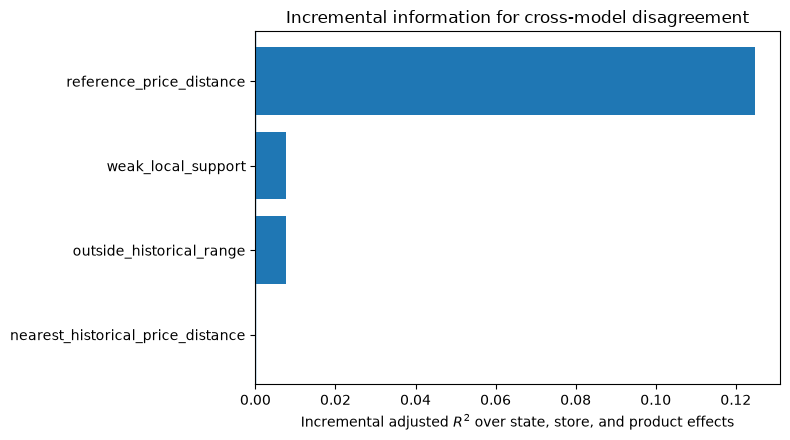

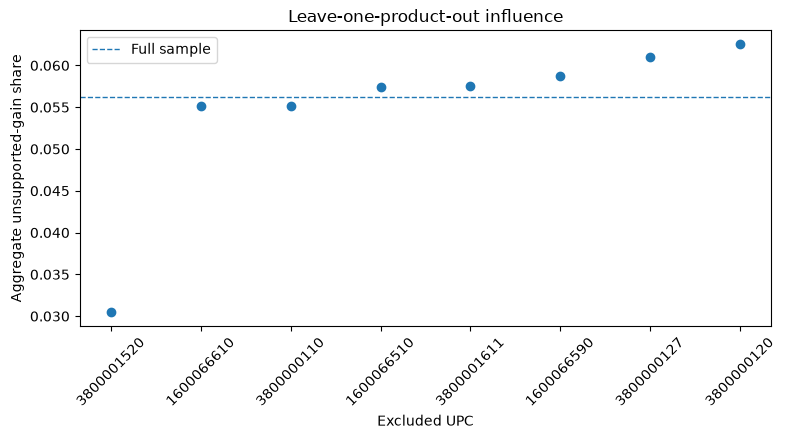

Saved: C:\Users\janza\price-of-extrapolation\results\figures\robustness_diagnostic_comparison.png
Saved: C:\Users\janza\price-of-extrapolation\results\figures\robustness_leave_one_product_out.png


In [11]:
# Figure 1: incremental adjusted R-squared by simple diagnostic.
figure_diagnostics = (
    diagnostic_comparison.loc[
        diagnostic_comparison[
            "evaluation_split"
        ].eq(
            PRIMARY_EVALUATION_SPLIT
        )
    ]
    .sort_values(
        "incremental_adjusted_r_squared"
    )
)

fig, ax = plt.subplots(
    figsize=(8, 4.5)
)

ax.barh(
    figure_diagnostics[
        "diagnostic"
    ],
    figure_diagnostics[
        "incremental_adjusted_r_squared"
    ],
)
ax.axvline(
    0.0,
    linewidth=1.0,
)
ax.set_xlabel(
    "Incremental adjusted $R^2$ over state, store, and product effects"
)
ax.set_ylabel("")
ax.set_title(
    "Incremental information for cross-model disagreement"
)
fig.tight_layout()

diagnostic_figure_path = (
    FIGURE_DIR
    / "robustness_diagnostic_comparison.png"
)
fig.savefig(
    diagnostic_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Figure 2: leave-one-product-out influence.
loo_plot = (
    leave_one_product_out.loc[
        leave_one_product_out[
            "excluded_upc"
        ].ne(
            "none_full_sample"
        )
    ]
    .copy()
    .sort_values(
        "aggregate_unsupported_share"
    )
)

full_unsupported_share = float(
    full_sample_metrics[
        "aggregate_unsupported_share"
    ]
)

fig, ax = plt.subplots(
    figsize=(8, 4.5)
)

ax.scatter(
    loo_plot[
        "excluded_upc"
    ].astype(str),
    loo_plot[
        "aggregate_unsupported_share"
    ],
)
ax.axhline(
    full_unsupported_share,
    linestyle="--",
    linewidth=1.0,
    label="Full sample",
)
ax.set_xlabel(
    "Excluded UPC"
)
ax.set_ylabel(
    "Aggregate unsupported-gain share"
)
ax.set_title(
    "Leave-one-product-out influence"
)
ax.tick_params(
    axis="x",
    rotation=45,
)
ax.legend()
fig.tight_layout()

leave_one_product_figure_path = (
    FIGURE_DIR
    / "robustness_leave_one_product_out.png"
)
fig.savefig(
    leave_one_product_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved:",
    diagnostic_figure_path,
)
print(
    "Saved:",
    leave_one_product_figure_path,
)

## 11. Save robustness outputs

In [12]:
output_paths = {
    "within_state_correlations": (
        TABLE_DIR
        / "robustness_within_state_correlations.csv"
    ),
    "regression_comparison": (
        TABLE_DIR
        / "robustness_disagreement_regressions.csv"
    ),
    "diagnostic_comparison": (
        TABLE_DIR
        / "robustness_diagnostic_comparison.csv"
    ),
    "bootstrap_main_metrics": (
        TABLE_DIR
        / "robustness_bootstrap_main_metrics.csv"
    ),
    "bootstrap_draws": (
        PROCESSED_DIR
        / "robustness_bootstrap_draws.pkl"
    ),
    "leave_one_product_out": (
        TABLE_DIR
        / "robustness_leave_one_product_out.csv"
    ),
    "boundary_diagnostics": (
        TABLE_DIR
        / "robustness_boundary_diagnostics.csv"
    ),
    "boundary_robustness": (
        TABLE_DIR
        / "robustness_boundary_checks.csv"
    ),
}

within_state_correlations.to_csv(
    output_paths[
        "within_state_correlations"
    ],
    index=False,
)
disagreement_regression_comparison.to_csv(
    output_paths[
        "regression_comparison"
    ],
    index=False,
)
diagnostic_comparison.to_csv(
    output_paths[
        "diagnostic_comparison"
    ],
    index=False,
)
bootstrap_main_metrics.to_csv(
    output_paths[
        "bootstrap_main_metrics"
    ],
    index=False,
)
bootstrap_draws.to_pickle(
    output_paths[
        "bootstrap_draws"
    ]
)
leave_one_product_out.to_csv(
    output_paths[
        "leave_one_product_out"
    ],
    index=False,
)
boundary_diagnostics.to_csv(
    output_paths[
        "boundary_diagnostics"
    ],
    index=False,
)
boundary_robustness.to_csv(
    output_paths[
        "boundary_robustness"
    ],
    index=False,
)

for name, path in (
    output_paths.items()
):
    print(
        f"Saved {name}:",
        path,
    )

Saved within_state_correlations: C:\Users\janza\price-of-extrapolation\results\tables\robustness_within_state_correlations.csv
Saved regression_comparison: C:\Users\janza\price-of-extrapolation\results\tables\robustness_disagreement_regressions.csv
Saved diagnostic_comparison: C:\Users\janza\price-of-extrapolation\results\tables\robustness_diagnostic_comparison.csv
Saved bootstrap_main_metrics: C:\Users\janza\price-of-extrapolation\results\tables\robustness_bootstrap_main_metrics.csv
Saved bootstrap_draws: C:\Users\janza\price-of-extrapolation\data\processed\robustness_bootstrap_draws.pkl
Saved leave_one_product_out: C:\Users\janza\price-of-extrapolation\results\tables\robustness_leave_one_product_out.csv
Saved boundary_diagnostics: C:\Users\janza\price-of-extrapolation\results\tables\robustness_boundary_diagnostics.csv
Saved boundary_robustness: C:\Users\janza\price-of-extrapolation\results\tables\robustness_boundary_checks.csv


## 12. Interpretation checklist

The robustness evidence supports the main paper claim only when the
following conditions hold:

- the support coefficient remains negative in the full evaluation-period
  regression;
- support adds explanatory power beyond distance and range diagnostics;
- the within-promotion relationship is not entirely absent;
- bootstrap intervals do not make the main concentration result
  uninformative;
- leave-one-product-out estimates remain qualitatively similar;
- excluding spline-clipped choices does not materially alter the result.

Candidate-grid boundary dependence should be interpreted rather than
automatically discarded. A high boundary-selection rate may indicate
either a genuinely monotone estimated revenue response or insufficiently
wide candidate sets. It is a diagnostic for the subsequent simulation
design.